<a href="https://colab.research.google.com/github/aitoufkir-khadija2004/Exercise-Pose-Correction-_Module-AAI/blob/main/AAI_Exercise_Pose_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 !pip install -q mediapipe opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

# Dossier de travail (Colab = /content/)
BASE = '/content/fitness_data'
os.makedirs(f'{BASE}/processed', exist_ok=True)
os.makedirs(f'{BASE}/results',   exist_ok=True)

# Style visuel dark (pour les graphiques)
BG, DARK = '#0f0f23', '#16213e'
C1, C2, C3, C4 = '#2ecc71', '#e74c3c', '#3498db', '#f39c12'
WHITE, GRAY = 'white', '#aaaaaa'

print(" Imports OK")
print(f" Dossiers créés dans {BASE}")

 Imports OK
 Dossiers créés dans /content/fitness_data


In [4]:

ANGLE_NAMES = [
    'genou_gauche', 'genou_droit',
    'hanche_gauche', 'hanche_droite',
    'coude_gauche', 'coude_droit',
    'tronc'
]

def calculate_angle(A, B, C):
    """
    Calcule l'angle en degrés au sommet B entre les segments BA et BC.
    A, B, C : arrays numpy de shape (2,) ou (3,) → coordonnées x,y[,z]
    """
    BA = A - B  # vecteur de B vers A
    BC = C - B  # vecteur de B vers C

    # Produit scalaire et normes
    cos_angle = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC) + 1e-8)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)  # sécurité numérique

    return np.degrees(np.arccos(cos_angle))  # en degrés, plus lisible

# Test rapide pour vérifier
A = np.array([0, 1])   # genou au-dessus
B = np.array([0, 0])   # articulation
C = np.array([1, 0])   # jambe vers la droite
print(f"Test angle à 90° → {calculate_angle(A, B, C):.1f}°  ")  # doit afficher 90.0



Test angle à 90° → 90.0°  


In [5]:

np.random.seed(42)

EXERCISES = {
    # nom : (angles_base_correct, angles_base_incorrect, description_erreur)
    'squat': {
        # angles en degrés pour chaque des 7 joints au bas du squat
        'correct':   np.array([90, 90, 110, 110, 170, 170, 175]),
        'incorrect': np.array([65, 65, 100, 100, 170, 170, 155]),
        #                      ↑ genoux valgus   ↑ tronc penché
        'erreur': 'Genou valgus + tronc penché'
    },
    'pushup': {
        'correct':   np.array([175, 175, 180, 180, 90,  90,  170]),
        'incorrect': np.array([175, 175, 160, 160, 90,  90,  150]),
        #                                 ↑ hanches affaissées ↑ tronc cassé
        'erreur': 'Hanches affaissées + tronc cassé'
    },
    'lunge': {
        'correct':   np.array([90,  170, 110, 170, 170, 170, 175]),
        'incorrect': np.array([75,  170, 125, 170, 170, 170, 155]),
        #                      ↑ genou trop en avant       ↑ tronc penché
        'erreur': 'Genou trop en avant + tronc penché'
    }
}

N_CORRECT   = 200   # séquences correctes par exercice
N_INCORRECT = 200   # séquences incorrectes par exercice
SEQ_LEN     = 60    # frames par séquence
N_FEATURES  = 7     # angles

def generate_sequence(angles_base, seq_len=60, noise_level=8, is_incorrect=False):
    """
    Génère une séquence temporelle réaliste d'angles articulaires.

    La trajectoire simule :
    - Phase descente (frames 0→30)  : les angles diminuent
    - Phase montée  (frames 30→60) : les angles remontent

    Args:
        angles_base  : angles cibles au point le plus bas du mouvement
        noise_level  : bruit gaussien ajouté (en degrés)
        is_incorrect : si True, ajoute des erreurs supplémentaires
    """
    angles_top  = np.array([170, 170, 175, 175, 170, 170, 178])  # position debout
    angles_down = angles_base.copy()

    sequence = []
    for frame in range(seq_len):
        # Interpolation sinusoïdale : mouvement naturel (pas linéaire)
        t = np.sin(np.pi * frame / seq_len)   # 0 → 1 → 0

        # Interpolation entre position debout et position basse
        angles = angles_top + t * (angles_down - angles_top)

        # Bruit gaussien = variabilité naturelle entre répétitions
        angles += np.random.normal(0, noise_level, N_FEATURES)

        # Pour les séquences incorrectes : erreur progressive
        if is_incorrect:
            error = np.random.normal(0, noise_level * 0.5, N_FEATURES)
            angles += error

        # Contraintes physiologiques : angles entre 0° et 180°
        angles = np.clip(angles, 5, 175)
        sequence.append(angles)

    return np.array(sequence)  # shape : (60, 7)


# ── Génération de toutes les séquences ──
X_list    = []  # liste des séquences (chacune = array 60×7)
y_list    = []  # labels (0 ou 1)
meta_list = []  # métadonnées (exercice, label texte)

for exercise, params in EXERCISES.items():
    # Séquences correctes (label = 0)
    for i in range(N_CORRECT):
        seq = generate_sequence(params['correct'], is_incorrect=False)
        X_list.append(seq)
        y_list.append(0)
        meta_list.append({'exercise': exercise, 'label': 0, 'label_str': 'correct'})

    # Séquences incorrectes (label = 1)
    for i in range(N_INCORRECT):
        seq = generate_sequence(params['incorrect'], is_incorrect=True)
        X_list.append(seq)
        y_list.append(1)
        meta_list.append({'exercise': exercise, 'label': 1, 'label_str': 'incorrect', 'erreur': params['erreur']})

X    = np.array(X_list)    # shape finale : (1200, 60, 7)
y    = np.array(y_list)    # shape finale : (1200,)
meta = pd.DataFrame(meta_list)

print(f" Dataset généré !")
print(f"   X shape : {X.shape}  →  (N_séquences, frames, angles)")
print(f"   y shape : {y.shape}  →  (N_séquences,)")
print(f"   Classes : {np.bincount(y)} [correct, incorrect] → dataset équilibré ")
print(f"   Exercices : {meta['exercise'].value_counts().to_dict()}")


 Dataset généré !
   X shape : (1200, 60, 7)  →  (N_séquences, frames, angles)
   y shape : (1200,)  →  (N_séquences,)
   Classes : [600 600] [correct, incorrect] → dataset équilibré 
   Exercices : {'squat': 400, 'pushup': 400, 'lunge': 400}


In [6]:
from sklearn.preprocessing import StandardScaler

N, T, F = X.shape  # 1200, 60, 7

# Le scaler travaille sur 2D → on reshape temporairement
# (N * T, F) = (72000, 7) : chaque frame est un exemple
scaler = StandardScaler()
X_norm = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)

print(f"✅ Normalisation OK")
print(f"   Avant : min={X.min():.1f}°  max={X.max():.1f}°  mean={X.mean():.1f}°")
print(f"   Après : min={X_norm.min():.2f}  max={X_norm.max():.2f}  mean={X_norm.mean():.3f}")


✅ Normalisation OK
   Avant : min=33.8°  max=175.0°  mean=150.7°
   Après : min=-4.73  max=1.19  mean=-0.000


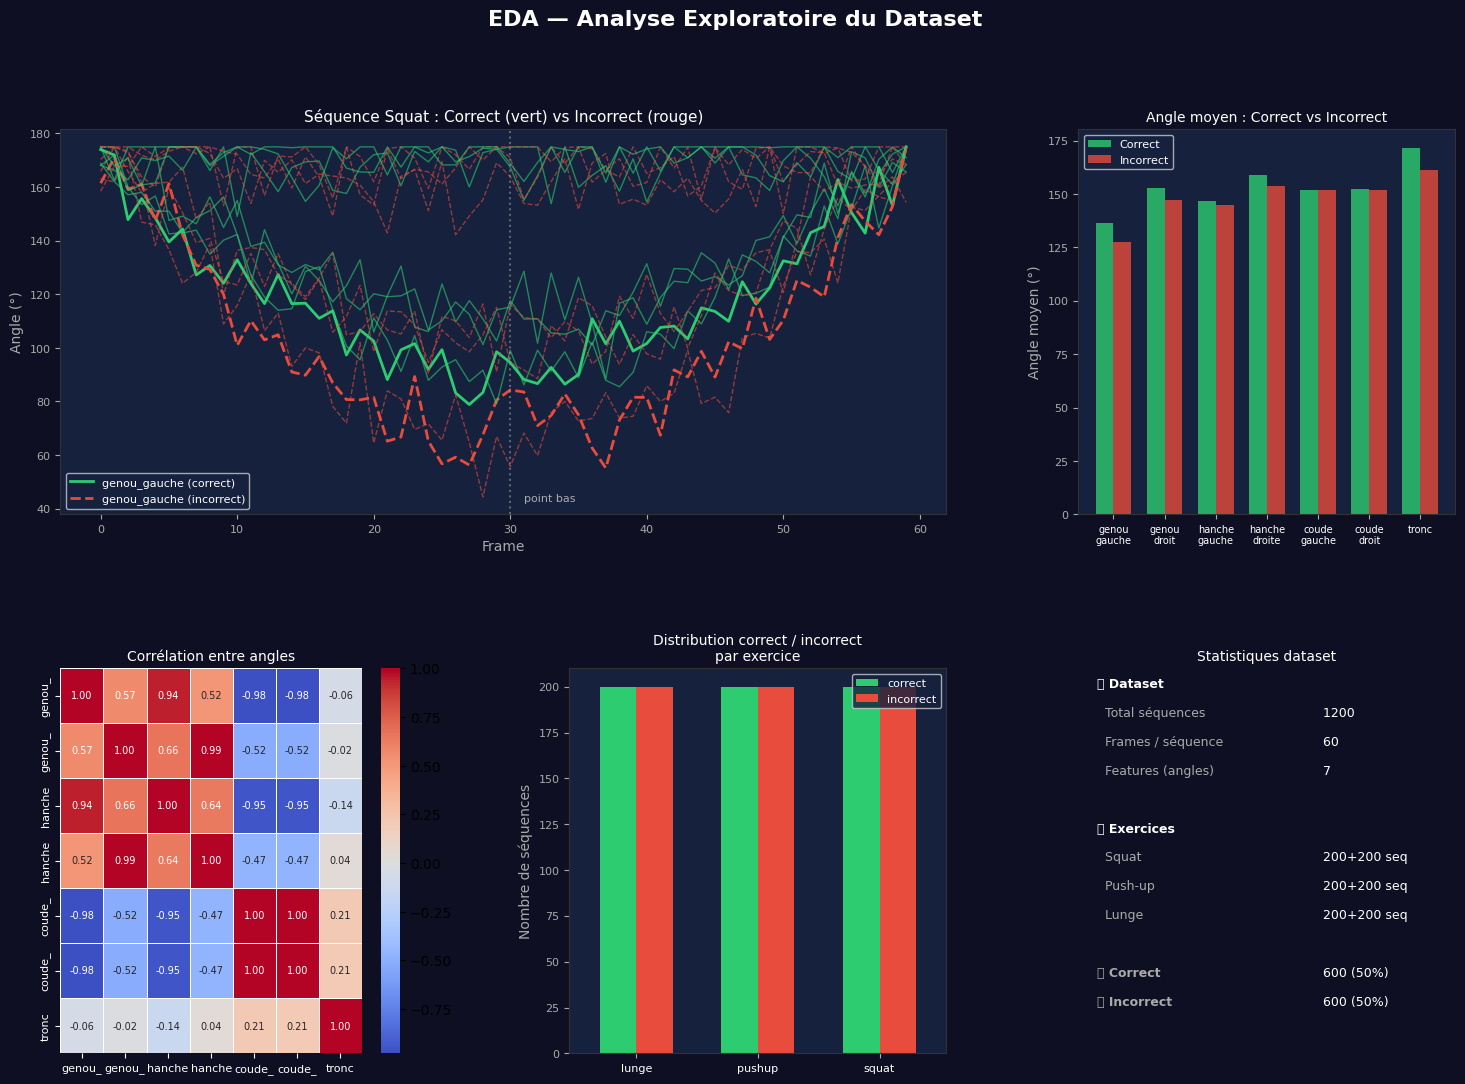

✅ Graphique EDA sauvegardé


In [7]:

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('EDA — Analyse Exploratoire du Dataset', color=WHITE, fontsize=16, fontweight='bold')

def style_ax(ax):
    ax.set_facecolor(DARK)
    ax.tick_params(colors=GRAY, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

# ── Figure 1 : Une séquence correcte vs incorrecte (squat) ──────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)
# On prend le 1er squat correct (index 0) et 1er squat incorrect (index 200)
seq_correct   = X[0]    # shape (60, 7)
seq_incorrect = X[200]  # shape (60, 7)

for i, name in enumerate(ANGLE_NAMES):
    alpha = 0.6 if i != 0 else 1.0  # mettre en avant le genou gauche
    lw    = 2   if i == 0 else 1
    ax1.plot(seq_correct[:, i],   color=C1, alpha=alpha, lw=lw,
             label=f'{name} (correct)'   if i == 0 else '')
    ax1.plot(seq_incorrect[:, i], color=C2, alpha=alpha, lw=lw, linestyle='--',
             label=f'{name} (incorrect)' if i == 0 else '')

ax1.axvline(30, color=GRAY, linestyle=':', alpha=0.5)
ax1.text(31, ax1.get_ylim()[0]+5, 'point bas', color=GRAY, fontsize=8)
ax1.set_title('Séquence Squat : Correct (vert) vs Incorrect (rouge)', color=WHITE, fontsize=11)
ax1.set_xlabel('Frame', color=GRAY)
ax1.set_ylabel('Angle (°)', color=GRAY)
ax1.legend(fontsize=8, facecolor=DARK, labelcolor=WHITE)

# ── Figure 2 : Distribution par classe pour chaque angle ────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2)
# Angle moyen par séquence pour chaque classe
X_mean = X.mean(axis=1)  # (1200, 7) : moyenne sur les 60 frames
df_viz = pd.DataFrame(X_mean, columns=ANGLE_NAMES)
df_viz['label'] = y

means_correct   = df_viz[df_viz.label==0][ANGLE_NAMES].mean()
means_incorrect = df_viz[df_viz.label==1][ANGLE_NAMES].mean()

x_pos = np.arange(len(ANGLE_NAMES))
width = 0.35
ax2.bar(x_pos - width/2, means_correct,   width, color=C1, alpha=0.8, label='Correct')
ax2.bar(x_pos + width/2, means_incorrect, width, color=C2, alpha=0.8, label='Incorrect')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([n.replace('_','\n') for n in ANGLE_NAMES], fontsize=7, color=WHITE)
ax2.set_title('Angle moyen : Correct vs Incorrect', color=WHITE, fontsize=10)
ax2.set_ylabel('Angle moyen (°)', color=GRAY)
ax2.legend(fontsize=8, facecolor=DARK, labelcolor=WHITE)

# ── Figure 3 : Heatmap de corrélation des angles ─────────────────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3)
corr = df_viz[ANGLE_NAMES].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, ax=ax3, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            xticklabels=[n[:6] for n in ANGLE_NAMES],
            yticklabels=[n[:6] for n in ANGLE_NAMES],
            linewidths=0.5)
ax3.set_title('Corrélation entre angles', color=WHITE, fontsize=10)
ax3.tick_params(colors=WHITE)

# ── Figure 4 : Distribution des labels par exercice ──────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4)
counts = meta.groupby(['exercise', 'label_str']).size().unstack()
counts.plot(kind='bar', ax=ax4, color=[C1, C2], width=0.6)
ax4.set_title('Distribution correct / incorrect\npar exercice', color=WHITE, fontsize=10)
ax4.set_xlabel('', color=GRAY)
ax4.set_ylabel('Nombre de séquences', color=GRAY)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0, color=WHITE)
ax4.legend(facecolor=DARK, labelcolor=WHITE, fontsize=8)

# ── Figure 5 : Statistiques globales ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(DARK)
ax5.axis('off')
stats = [
    ('📊 Dataset', '', ''),
    ('  Total séquences', str(N), ''),
    ('  Frames / séquence', str(T), ''),
    ('  Features (angles)', str(F), ''),
    ('', '', ''),
    ('🏋️ Exercices', '', ''),
    ('  Squat',   f'{N_CORRECT}+{N_INCORRECT}', 'seq'),
    ('  Push-up', f'{N_CORRECT}+{N_INCORRECT}', 'seq'),
    ('  Lunge',   f'{N_CORRECT}+{N_INCORRECT}', 'seq'),
    ('', '', ''),
    ('✅ Correct',   str(np.sum(y==0)), f'({np.mean(y==0)*100:.0f}%)'),
    ('❌ Incorrect', str(np.sum(y==1)), f'({np.mean(y==1)*100:.0f}%)'),
]
for i, (label, val, unit) in enumerate(stats):
    y_pos = 0.95 - i * 0.075
    ax5.text(0.05, y_pos, label, transform=ax5.transAxes,
             color=GRAY if not label.startswith(('📊','🏋️')) else WHITE,
             fontsize=9, fontweight='bold' if label.startswith(('📊','🏋️','✅','❌')) else 'normal')
    ax5.text(0.65, y_pos, f'{val} {unit}', transform=ax5.transAxes,
             color=WHITE, fontsize=9)

ax5.set_title('Statistiques dataset', color=WHITE, fontsize=10)

plt.savefig(f'{BASE}/results/eda_jour1.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"✅ Graphique EDA sauvegardé")

In [8]:
np.save(f'{BASE}/processed/X.npy', X_norm)
np.save(f'{BASE}/processed/y.npy', y)
meta.to_csv(f'{BASE}/processed/meta.csv', index=False)
with open(f'{BASE}/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Dataset sauvegardé dans /content/fitness_data/processed/")
print(f"   X.npy     : {X_norm.shape}  ({X_norm.nbytes / 1024:.0f} KB)")
print(f"   y.npy     : {y.shape}")
print(f"   meta.csv  : {len(meta)} lignes")
print(f"   scaler.pkl: StandardScaler avec mean/std de {F} features")

✅ Dataset sauvegardé dans /content/fitness_data/processed/
   X.npy     : (1200, 60, 7)  (3938 KB)
   y.npy     : (1200,)
   meta.csv  : 1200 lignes
   scaler.pkl: StandardScaler avec mean/std de 7 features
